# Do other models' translations agree? A consensus metric for NL→FOL faithfulness

This notebook demos **candidate C**, a faithfulness metric for natural-language → first-order-logic translation that needs
**no gold formula and no text**. For a candidate formula `c` of sentence `t` we ask several *other* systems to translate `t`
and measure

- **`c_score = 1 − eq_frac`**: the share of the other systems' translations that are **not** z3-equivalent to `c`
  *modulo vocabulary alignment* (predicate/constant renaming plus merge/split "granularity bridges");
- **medoid repair depth / operators**: the smallest typed edit sequence (NEG, QUANT, DROP, ADD, SWAP, …) that turns `c`
  into the pool medoid. This is a guess at the *kind* of error;
- **cluster entropy**: semantic entropy over the z3-equivalence classes of the pool ∪ {c}.

The pool holds 6 fresh OpenRouter models (llama-3.3-70b, qwen3-235b, deepseek-v3.1, mistral-small-3.2,
gemini-2.5-flash-lite, gpt-4.1-mini) plus the 3 released Logic-LM systems (gpt-3.5-turbo, gpt-4, text-davinci-003),
used **leave-one-system-out**. The baseline is **K=5 self-consistency** (`sc5`): the share of five T=0.7 samples that are equivalent to `c`.

**Ground truth** comes from prover-checked equivalence to the (curated) FOLIO gold: CORRECT vs ERROR candidates.
Full-run headline (546 items): **c_score AUROC 0.866 [0.821, 0.906]** vs **sc5_cheap 0.725**.

**What runs here.** The original `method.py` is a thin orchestrator that runs the `src/` modules as subprocesses
(OpenRouter calls → pairwise z3 equivalence → consensus scores → analysis). The LLM translations are already cached, so
this notebook loads a **100-candidate, 35-sentence subset** of the primary contrast *with the pools and SC samples attached*,
and then re-runs everything after the API calls **live with z3**: the FOL parser, the vocabulary aligner, pairwise equivalence,
consensus scoring, medoid repair search, and the sentence-clustered bootstrap AUROC. The code in each cell is copied from
the original `src/*.py` files.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru — NOT on Colab, always install (versions from the artifact's pyproject.toml)
_pip('z3-solver==5.1.0.0', 'loguru==0.7.3')

# numpy, pandas, sklearn, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# Original imports of src/fol.py, src/repair_census.py, src/common.py, src/consensus.py, src/analysis.py
from __future__ import annotations

import hashlib
import itertools
import json
import math
import random
import re
import sys
import time
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import z3
from loguru import logger
from scipy.stats import rankdata
from sklearn.metrics import average_precision_score

# notebook additions
import matplotlib.pyplot as plt

sys.setrecursionlimit(10000)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_e4aqYfQhdCkX/round-1/experiment-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["dataset"], "|", len(data["sentences"]), "sentences |", len(data["items"]), "candidates")
print(Counter(x["label"] for x in data["items"]), Counter(x["system"] for x in data["items"]))

logiclm_folio_dev_trackL | 35 sentences | 100 candidates
Counter({'CORRECT': 53, 'ERROR': 47}) Counter({'gpt-4': 38, 'gpt-3.5-turbo': 33, 'text-davinci-003': 29})


## Configuration

Every tunable parameter is set here. These **are the original values** (`consensus.py --budget 10`, `analysis.py --boot 2000`, `eqmv ms=3000`). The z3 stages take about 20 s on a CPU. The only reduction is the data: 35 sentences / 100 candidates instead of 192 / 546. Lower `N_SENTENCES`, `REPAIR_BUDGET_S` or `BOOT` for a quicker smoke run.

In [5]:
N_SENTENCES = 35        # sentences taken from the demo subset (35 = all of it; original: 192 track-L sentences / 546 candidates)
REPAIR_BUDGET_S = 10.0  # medoid typed-repair search budget per candidate, seconds (original: --budget 10.0)
EQMV_MS = 3000          # z3 timeout per equivalence-modulo-vocabulary check, ms (original: eqmv(ms=3000))
BOOT = 2000             # sentence-clustered bootstrap resamples for AUROC CIs (original: --boot 2000)

## The original entry point (`method.py`)

`method.py` only runs the stages in order. Each stage is a module in `src/`, and the OpenRouter responses are cached, so a
re-run does not re-bill. Stages 1–3 (tests, building the labelled screen, calling OpenRouter for peers and SC samples) produce
the data this notebook loads. Everything from `src/consensus.py` onwards is reproduced in the cells below.

```python
#!/usr/bin/env python3
"""Entry point: candidate C (cross-system z3 consensus) + self-consistency baselines on the frozen NL->FOL screen.

Runs the full pipeline in order (each stage is a module in src/; OpenRouter responses are cached in data/peer_raw/,
so a re-run does not re-bill). Stages: T0 tests -> screen (labels + hash) -> peers / SC sampling -> build ->
consensus (T3 mini, then full) -> analysis (writes results/summary.json + method_out.json) -> previews.

usage: python method.py [--skip-api] [--boot 2000]
"""
import argparse
import os
import subprocess
import sys
from pathlib import Path

from loguru import logger

ROOT = Path(__file__).resolve().parent
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")


def run(args: list[str]) -> None:
    logger.info("$ " + " ".join(args))
    env = {**os.environ, "PYTHONHASHSEED": "0"}
    subprocess.run([sys.executable, *args], cwd=ROOT, env=env, check=True)


@logger.catch(reraise=True)
def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--skip-api", action="store_true", help="do not call OpenRouter; use cached responses only")
    ap.add_argument("--boot", type=int, default=2000)
    a = ap.parse_args()
    run(["-m", "pytest", "-c", "/dev/null", "--rootdir", ".", "--noconftest", "-q", "tests/test_fol.py"])
    run(["tests/census_regression.py"])
    run(["src/screen.py"])
    if not a.skip_api:
        for arm in ("peers", "sc_cheap", "sc_same"):
            run(["src/peers.py", "call", "--arm", arm])
    run(["src/peers.py", "build"])
    run(["src/consensus.py", "--mini", "20"])
    run(["src/consensus.py"])
    run(["src/analysis.py", "--boot", str(a.boot)])
    run(["tests/audit_rederive.py"])
    logger.info("done: method_out.json, results/summary.json, results/audit_rederive.json")


if __name__ == "__main__":
    main()
```

## 1. FOL parser and z3 translation (`src/fol.py`)

This parses Unicode FOLIO/MALLS notation (`∀ ∃ ¬ ∧ ∨ → ↔ ⊕`) into a tuple AST and translates it into z3 over one uninterpreted sort
`U`. `equivalent(e1, e2)` asks z3 whether `e1 ↔ e2` is valid: `True` means proved equivalent, `False` means a
countermodel was found, and `None` means timeout. Precedence, lowest to highest: `↔ < → < ∨/⊕ < ∧ < ¬`. A quantifier binds the
next group.

In [6]:
"""Unicode FOL (FOLIO/MALLS notation) -> AST -> z3; semantic monotonicity profile per predicate.

Grammar (lowest to highest precedence): ↔  <  →  <  ∨ / ⊕  <  ∧  <  ¬, quantifiers, atoms.
(iter-1 GEN_ART fix: ⊕ now binds like ∨, i.e. tighter than →, so "A ⊕ B → C" is "(A ⊕ B) → C";
 the iter-3 probe version gave ⊕ the precedence of ↔, which created false COMPOUND census classes.)
A quantifier binds the immediately following parenthesised group, atom, negation or quantifier
(FOLIO/MALLS convention: '∀x (A(x)) ∧ ∀y (B(y))' is two sentences).
"""

TOK = re.compile(r"\s*(∀|∃|¬|∧|∨|→|↔|⊕|\(|\)|,|[A-Za-z_][A-Za-z0-9_'\-]*)")
OPS = {"↔": "iff", "⊕": "xor", "→": "imp", "∨": "or", "∧": "and"}
PREC = {"iff": 1, "imp": 2, "xor": 3, "or": 3, "and": 4}


def tokenize(s: str) -> list[str]:
    s = s.replace("⇒", "→").replace("->", "→").replace("<->", "↔").replace("&", "∧").replace("|", "∨")
    s = s.replace("~", "¬").replace("!", "¬").replace("¬", "¬").replace("−", "-")
    pos, out = 0, []
    s = s.strip().rstrip(".")
    while pos < len(s):
        m = TOK.match(s, pos)
        if not m:
            raise ValueError(f"bad char at {pos}: {s[pos:pos+10]!r}")
        out.append(m.group(1))
        pos = m.end()
        while pos < len(s) and s[pos].isspace():
            pos += 1
    return out


class Parser:
    def __init__(self, s: str):
        self.t = tokenize(s)
        self.i = 0

    def peek(self):
        return self.t[self.i] if self.i < len(self.t) else None

    def eat(self, x=None):
        tok = self.peek()
        if x is not None and tok != x:
            raise ValueError(f"expected {x} got {tok}")
        self.i += 1
        return tok

    def parse(self):
        e = self.expr(0)
        if self.peek() is not None:
            raise ValueError(f"trailing {self.t[self.i:]}")
        return e

    def expr(self, minp):
        lhs = self.unary()
        while self.peek() in OPS and PREC[OPS[self.peek()]] > minp - 1 and PREC[OPS[self.peek()]] >= minp:
            op = OPS[self.eat()]
            # → is right-assoc, others left-assoc
            nxt = PREC[op] if op == "imp" else PREC[op] + 1
            rhs = self.expr(nxt)
            lhs = (op, lhs, rhs)
        return lhs

    def unary(self):
        tok = self.peek()
        if tok == "¬":
            self.eat()
            return ("not", self.unary())
        if tok in ("∀", "∃"):
            self.eat()
            vs = [self.eat()]
            while self.peek() not in ("(", "¬", "∀", "∃") and self.peek() is not None and re.match(r"^[a-z][a-z0-9]*$", self.peek() or "") and not self._is_atom_start():
                vs.append(self.eat())
            body = self.unary()  # FOLIO/MALLS convention: a quantifier binds the next group/atom/quantifier
            for v in reversed(vs):
                body = ("all" if tok == "∀" else "ex", v, body)
            return body
        if tok == "(":
            self.eat("(")
            e = self.expr(0)
            self.eat(")")
            return e
        name = self.eat()
        if self.peek() == "(":
            self.eat("(")
            args = [self.eat()]
            while self.peek() == ",":
                self.eat(",")
                args.append(self.eat())
            self.eat(")")
            return ("atom", name, tuple(args))
        return ("atom", name, ())  # propositional atom

    def _is_atom_start(self):
        return self.i + 1 < len(self.t) and self.t[self.i + 1] == "("


def parse(s: str):
    return Parser(s).parse()


def preds(e, acc=None):
    acc = {} if acc is None else acc
    if e[0] == "atom":
        acc[f"{e[1]}/{len(e[2])}"] = len(e[2])  # key by name/arity: arity clashes are distinct symbols
    elif e[0] in ("all", "ex"):
        preds(e[2], acc)
    elif e[0] == "not":
        preds(e[1], acc)
    else:
        preds(e[1], acc)
        preds(e[2], acc)
    return acc


U = z3.DeclareSort("U")


def to_z3(e, env, P):
    k = e[0]
    if k in ("all", "ex"):
        v = z3.Const(e[1], U)
        env2 = dict(env)
        env2[e[1]] = v
        b = to_z3(e[2], env2, P)
        return z3.ForAll([v], b) if k == "all" else z3.Exists([v], b)
    if k == "not":
        return z3.Not(to_z3(e[1], env, P))
    if k == "atom":
        args = [env.get(a, z3.Const("c_" + a, U)) for a in e[2]]
        f = P[f"{e[1]}/{len(e[2])}"]
        return f(*args) if args else f
    a, b = to_z3(e[1], env, P), to_z3(e[2], env, P)
    return {"and": lambda: z3.And(a, b), "or": lambda: z3.Or(a, b), "imp": lambda: z3.Implies(a, b),
            "iff": lambda: a == b, "xor": lambda: z3.Xor(a, b)}[k]()


def mkpred(name, n):
    name = name.replace("/", "_a")
    return z3.Function(name, *([U] * n), z3.BoolSort()) if n else z3.Bool(name)


def valid(c, ms=3000):
    s = z3.Solver()
    s.set("timeout", ms)
    s.add(z3.Not(c))
    r = s.check()
    return True if r == z3.unsat else (False if r == z3.sat else None)


def profile(e, ms=3000):
    """Semantic monotonicity of formula e in each predicate: UP / DOWN / VACUOUS / NONMONO / UNKNOWN."""
    ar = preds(e)
    base = {q: mkpred(q, m) for q, m in ar.items()}
    out = {}
    for p, n in ar.items():
        alt = dict(base)
        alt[p] = mkpred(p + "_prime", n)
        xs = [z3.Const(f"_x{i}", U) for i in range(n)]
        sub = z3.ForAll(xs, z3.Implies(base[p](*xs), alt[p](*xs))) if n else z3.Implies(base[p], alt[p])
        F, Fp = to_z3(e, {}, base), to_z3(e, {}, alt)
        up, down = valid(z3.Implies(z3.And(sub, F), Fp), ms), valid(z3.Implies(z3.And(sub, Fp), F), ms)
        if up is None or down is None:
            out[p] = "UNKNOWN"
        else:
            out[p] = {(True, True): "VACUOUS", (True, False): "UP", (False, True): "DOWN", (False, False): "NONMONO"}[(up, down)]
    return out


def equivalent(e1, e2, ms=5000):
    ar = {**preds(e1), **preds(e2)}
    P = {q: mkpred(q, m) for q, m in ar.items()}
    return valid(to_z3(e1, {}, P) == to_z3(e2, {}, P), ms)


def connectivity_flags(e):
    """Binding check: inside each quantifier scope, variables must be linked through shared atoms.
    Returns list of variables that are quantified but share no atom with any other variable in the
    same top-level sentence while other variables exist (an 'island')."""
    atoms = []

    def walk(x):
        if x[0] == "atom":
            atoms.append(set(a for a in x[2]))
        elif x[0] in ("all", "ex"):
            walk(x[2])
        elif x[0] == "not":
            walk(x[1])
        else:
            walk(x[1]); walk(x[2])

    def qvars(x, acc):
        if x[0] in ("all", "ex"):
            acc.append(x[1]); qvars(x[2], acc)
        elif x[0] == "not":
            qvars(x[1], acc)
        elif x[0] != "atom":
            qvars(x[1], acc); qvars(x[2], acc)
        return acc

    walk(e)
    vs = qvars(e, [])
    if len(vs) < 2:
        return []
    # union-find over variables via atoms
    parent = {v: v for v in vs}

    def f(v):
        while parent[v] != v:
            v = parent[v]
        return v
    for a in atoms:
        a = [v for v in a if v in parent]
        for v in a[1:]:
            parent[f(v)] = f(a[0])
    comps = {}
    for v in vs:
        comps.setdefault(f(v), []).append(v)
    if len(comps) == 1:
        return []
    main = max(comps.values(), key=len)
    return [v for c in comps.values() if c is not main for v in c]


def prenex_blocks(e):
    """Split a formula into top-level conjuncts; for each, collect its leading quantifier block."""
    parts = []

    def flat(x):
        if x[0] == "and":
            flat(x[1]); flat(x[2])
        else:
            parts.append(x)
    flat(e)
    return parts


def coupled_independent_vars(e):
    """GLUE check: within ONE top-level conjunct, >=2 universally quantified variables that never
    co-occur in any atom, i.e. independent generic claims wrongly bundled under a joint quantifier
    ('∀x∀y (Wolf(x) ∧ Bird(y) → Howls(x) ∧ Chirps(y))'). Returns True if any conjunct has one."""
    for part in prenex_blocks(e):
        if connectivity_flags(part):
            return True
    return False


def token_profile(prof):
    """Project a predicate-level polarity profile onto CamelCase word tokens, so that merged
    (WorksInNewsIndustryAndReportsOnEvents) and split (WorksInNewsIndustry ∧ ReportsOnEvents)
    renderings of the same concept get the same profile."""
    import re as _re
    STOP = {"and", "or", "of", "in", "on", "the", "a", "an", "to", "is", "has", "have", "can", "for", "with", "by", "at", "from"}
    out = {}
    for key, pol in prof.items():
        name = key.split("/")[0]
        for w in _re.findall(r"[A-Z]?[a-z]+|[A-Z]+(?![a-z])|\d+", name):
            w = w.lower()
            if w in STOP:
                continue
            w = w[:-1] if w.endswith("s") and len(w) > 3 else w
            out.setdefault(w, set()).add(pol)
    return out

## 2. Vocabulary alignment, granularity bridges, random-model fingerprint and typed repair search (`src/repair_census.py`)

These are the building blocks of *equivalence modulo vocabulary*:

- `align(old, new)`: renames predicates and constants of `old` onto those of `new` when the arity matches and the names are close
  (CamelCase-token Jaccard ≥ 0.5 or char-trigram Dice ≥ 0.6);
- `gran_bridge(ao, new)`: definitional merge/split bridges (`P(x) := Q1(x) ∧ Q2(x)` when the tokens match, plus reification
  `P(x) := Q(x, c)`);
- `fp(e)`: a cheap fingerprint from 24 random finite models. Different fingerprints prove non-equivalence without calling z3;
- `edits` / `search`: breadth-first search, depth ≤ 2, over **typed operators** (NEG, REV, QUANT, RESTR, CONN, DROP, ADD, SWAP,
  BIND, SCOPE, UNGLUE, MOVE). The labeller uses it to type the gold errors, and the metric uses it for the *medoid repair*.

(The census-only entry points `load/pairs/work/main`, which read the curated FOLIO/MALLS files, are omitted. Nothing below uses them.)

In [7]:
TOKRE = re.compile(r"[A-Z]?[a-z]+|[A-Z]+(?![a-z])|\d+")
STOP = {"and", "or", "of", "in", "on", "the", "a", "an", "to", "is", "has", "have", "can", "for", "with", "by", "at", "from", "be", "are"}
BIN = ("and", "or", "imp", "iff", "xor")


def toks(name):
    out = []
    for w in TOKRE.findall(name.replace("_", " ")):
        w = w.lower()
        if w in STOP:
            continue
        out.append(w[:-1] if w.endswith("s") and len(w) > 3 else w)
    return out


def tri(s):
    s = re.sub(r"[^a-z0-9]", "", s.lower())
    return {s[i:i + 3] for i in range(max(1, len(s) - 2))}


def dice(a, b):
    A, B = tri(a), tri(b)
    return 2 * len(A & B) / max(1, len(A) + len(B))


# ---------------------------------------------------------------- AST utilities
def atoms(e, acc=None):
    acc = [] if acc is None else acc
    if e[0] == "atom":
        acc.append(e)
    elif e[0] in ("all", "ex"):
        atoms(e[2], acc)
    elif e[0] == "not":
        atoms(e[1], acc)
    else:
        atoms(e[1], acc); atoms(e[2], acc)
    return acc


def bound_vars(e, acc=None):
    acc = set() if acc is None else acc
    if e[0] in ("all", "ex"):
        acc.add(e[1]); bound_vars(e[2], acc)
    elif e[0] == "not":
        bound_vars(e[1], acc)
    elif e[0] != "atom":
        bound_vars(e[1], acc); bound_vars(e[2], acc)
    return acc


def symbols(e):
    bv = bound_vars(e)
    P, C = {}, set()
    for a in atoms(e):
        P[(a[1], len(a[2]))] = True
        for x in a[2]:
            if x not in bv:
                C.add(x)
    return set(P), C


def rename(e, pmap, cmap, bv=frozenset()):
    k = e[0]
    if k == "atom":
        return ("atom", pmap.get((e[1], len(e[2])), e[1]), tuple(x if x in bv else cmap.get(x, x) for x in e[2]))
    if k in ("all", "ex"):
        return (k, e[1], rename(e[2], pmap, cmap, bv | {e[1]}))
    if k == "not":
        return ("not", rename(e[1], pmap, cmap, bv))
    return (k, rename(e[1], pmap, cmap, bv), rename(e[2], pmap, cmap, bv))


def expand(e, defs):
    """defs: {(name, arity): [name1, name2]}  P(args) -> Q1(args) & Q2(args)"""
    k = e[0]
    if k == "atom":
        key = (e[1], len(e[2]))
        if key in defs:
            q = defs[key]
            out = ("atom", q[0], e[2])
            for n in q[1:]:
                out = ("and", out, ("atom", n, e[2]))
            return out
        return e
    if k in ("all", "ex"):
        return (k, e[1], expand(e[2], defs))
    if k == "not":
        return ("not", expand(e[1], defs))
    return (k, expand(e[1], defs), expand(e[2], defs))


def align(old, new):
    Po, Co = symbols(old)
    Pn, Cn = symbols(new)
    pmap, used = {}, set()
    cands = []
    for p in Po - Pn:
        for q in Pn - Po:
            if p[1] != q[1]:
                continue
            to, tn = set(toks(p[0])), set(toks(q[0]))
            j = len(to & tn) / max(1, len(to | tn))
            s = max(j, dice(p[0], q[0]))
            if p[0].lower() == q[0].lower():
                s = 2
            if j >= 0.5 or dice(p[0], q[0]) >= 0.6 or s == 2:
                cands.append((s, p, q))
    for s, p, q in sorted(cands, reverse=True):
        if p in pmap or q in used:
            continue
        pmap[p] = q[0]; used.add(q)
    cmap, cused = {}, set()
    norm = lambda s: re.sub(r"[^a-z0-9]", "", s.lower())
    for c in Co - Cn:
        best = None
        for d in Cn - Co:
            if d in cused:
                continue
            a, b = norm(c), norm(d)
            if a == b or (min(len(a), len(b)) >= 4 and (a in b or b in a)) or dice(c, d) >= 0.7:
                best = d
                break
        if best:
            cmap[c] = best; cused.add(best)
    return rename(old, pmap, cmap), pmap, cmap


def gran_bridge(ao, new):
    """Try merge/split definitional bridges between leftover predicates of the aligned original and corrected."""
    Po, _ = symbols(ao)
    Pn, _ = symbols(new)
    lo, ln = Po - Pn, Pn - Po
    defs_old, defs_new = {}, {}
    for p in lo:  # original merged predicate -> corrected split pair
        tp = sorted(toks(p[0]))
        for q1, q2 in itertools.combinations([q for q in ln if q[1] == p[1]], 2):
            if sorted(toks(q1[0]) + toks(q2[0])) == tp or set(toks(q1[0]) + toks(q2[0])) == set(tp):
                defs_old[p] = [q1[0], q2[0]]
    for q in ln:  # corrected merged predicate -> original split pair
        tq = sorted(toks(q[0]))
        for p1, p2 in itertools.combinations([p for p in lo if p[1] == q[1]], 2):
            if sorted(toks(p1[0]) + toks(p2[0])) == tq or set(toks(p1[0]) + toks(p2[0])) == set(tq):
                defs_new[q] = [p1[0], p2[0]]
    _, Cn = symbols(new)
    reify = {}
    for p in lo:  # P(x) := Q(x, c) when tokens(P) == tokens(Q) + tokens(c)
        for q in ln:
            if q[1] != p[1] + 1:
                continue
            for c in Cn:
                if set(toks(q[0]) + toks(c)) == set(toks(p[0])):
                    reify[p] = (q[0], c)
    if not defs_old and not defs_new and not reify:
        return None
    return reify_expand(expand(ao, defs_old), reify), expand(new, defs_new)


def reify_expand(e, reify):
    k = e[0]
    if k == "atom":
        key = (e[1], len(e[2]))
        if key in reify:
            q, c = reify[key]
            return ("atom", q, e[2] + (c,))
        return e
    if k in ("all", "ex"):
        return (k, e[1], reify_expand(e[2], reify))
    if k == "not":
        return ("not", reify_expand(e[1], reify))
    return (k, reify_expand(e[1], reify), reify_expand(e[2], reify))


# ---------------------------------------------------------------- random-model fingerprint (necessary condition)
SEEDS = list(range(24))


def ev(e, m, env, dom, seed):
    k = e[0]
    if k == "atom":
        args = tuple(env[x] if x in env else (hash((seed, "c", x)) % dom) for x in e[2])
        return (hash((seed, e[1], len(e[2]), args)) >> 3) & 1 == 1
    if k == "all":
        return all(ev(e[2], m, {**env, e[1]: d}, dom, seed) for d in range(dom))
    if k == "ex":
        return any(ev(e[2], m, {**env, e[1]: d}, dom, seed) for d in range(dom))
    if k == "not":
        return not ev(e[1], m, env, dom, seed)
    a, b = ev(e[1], m, env, dom, seed), ev(e[2], m, env, dom, seed)
    return {"and": a and b, "or": a or b, "imp": (not a) or b, "iff": a == b, "xor": a != b}[k]


def fp(e):
    return tuple(ev(e, None, {}, 3, s) for s in SEEDS)


# ---------------------------------------------------------------- typed operators
def subterms(e, path=(), scope=()):
    yield path, e, scope
    k = e[0]
    if k in ("all", "ex"):
        yield from subterms(e[2], path + (2,), scope + (e[1],))
    elif k == "not":
        yield from subterms(e[1], path + (1,), scope)
    elif k != "atom":
        yield from subterms(e[1], path + (1,), scope)
        yield from subterms(e[2], path + (2,), scope)


def replace(e, path, new):
    if not path:
        return new
    i = path[0]
    lst = list(e)
    lst[i] = replace(e[i], path[1:], new)
    return tuple(lst)


def parent_kind(e, path):
    if not path:
        return None
    x = e
    for i in path[:-1]:
        x = x[i]
    return x[0]


def unglue(node):
    """∀x∀y (A(x) ∧ B(y) → C(x) ∧ D(y))  ->  ∀x (A(x) → C(x)) ∧ ∀y (B(y) → D(y))"""
    vs, body = [], node
    while body[0] == "all":
        vs.append(body[1]); body = body[2]
    if len(vs) < 2 or body[0] != "imp":
        return None

    def conj(x):
        return conj(x[1]) + conj(x[2]) if x[0] == "and" else [x]

    def vars_of(x):
        return {a for at in atoms(x) for a in at[2] if a in vs}
    ant, con = conj(body[1]), conj(body[2])
    groups = []
    for v in vs:
        a = [x for x in ant if vars_of(x) == {v}]
        c = [x for x in con if vars_of(x) == {v}]
        if not c:
            return None
        groups.append((v, a, c))
    if sum(len(g[1]) for g in groups) != len(ant) or sum(len(g[2]) for g in groups) != len(con):
        return None

    def mk(lst, op="and"):
        out = lst[0]
        for x in lst[1:]:
            out = (op, out, x)
        return out
    parts = [("all", v, ("imp", mk(a), mk(c)) if a else mk(c)) for v, a, c in groups]
    return mk(parts)


def edits(e, target):
    """Yield (op_label, candidate) for every single typed edit of e."""
    tgt_atoms = atoms(target)
    Pe, _ = symbols(e)
    _, Ct = symbols(target)
    new_atoms = [a for a in tgt_atoms if (a[1], len(a[2])) not in Pe]
    for path, node, scope in list(subterms(e)):
        k = node[0]
        # NEG
        if k == "not":
            yield "NEG", replace(e, path, node[1])
        else:
            yield "NEG", replace(e, path, ("not", node))
        if k in ("all", "ex"):
            yield "QUANT", replace(e, path, ("ex" if k == "all" else "all", node[1], node[2]))
            # block flip with the restrictor convention: ∀x∀y(A→B) <-> ∃x∃y(A∧B)
            vs, body = [], node
            while body[0] == k:
                vs.append(body[1]); body = body[2]
            if body[0] in ("imp", "and"):
                nb = ("and" if body[0] == "imp" else "imp", body[1], body[2])
                q = "ex" if k == "all" else "all"
                for v in reversed(vs):
                    nb = (q, v, nb)
                yield "QUANT", replace(e, path, nb)
            if node[2][0] in ("all", "ex"):
                inner = node[2]
                yield "SCOPE", replace(e, path, (inner[0], inner[1], (k, node[1], inner[2])))
            ug = unglue(node) if k == "all" else None
            if ug is not None:
                yield "UNGLUE", replace(e, path, ug)
        if k in ("imp", "iff") and node[1][0] == "and":
            # MOVE: pull a conjunct of the left side out as an outer restriction: (A ∧ B op C) -> (A -> (B op C))
            yield "MOVE", replace(e, path, ("imp", node[1][1], (k, node[1][2], node[2])))
            yield "MOVE", replace(e, path, ("imp", node[1][2], (k, node[1][1], node[2])))
        if k == "imp" and node[2][0] == "imp":
            # MOVE inverse: A -> (B -> C)  <->  (A ∧ C) -> B style condition/consequence exchange
            yield "MOVE", replace(e, path, ("imp", ("and", node[1], node[2][2]), node[2][1]))
        if k in BIN:
            if k == "imp":
                yield "REV", replace(e, path, ("imp", node[2], node[1]))
            for op in BIN:
                if op != k:
                    lab = "RESTR" if {k, op} == {"imp", "and"} and parent_kind(e, path) in ("all", "ex") else "CONN"
                    yield lab, replace(e, path, (op, node[1], node[2]))
            if k in ("and", "or"):
                yield "DROP", replace(e, path, node[1])
                yield "DROP", replace(e, path, node[2])
        if k == "atom":
            args = node[2]
            if len(args) >= 2:
                for perm in set(itertools.permutations(args)):
                    if perm != args:
                        yield "SWAP", replace(e, path, ("atom", node[1], perm))
            pool = set(scope) | Ct
            for i, a in enumerate(args):
                for b in pool:
                    if b != a:
                        yield "BIND", replace(e, path, ("atom", node[1], args[:i] + (b,) + args[i + 1:]))
        # ADD: conjoin a corrected-only atom (args re-bound to in-scope variables when its variables are foreign)
        if k != "atom" or True:
            for a in new_atoms:
                sc = list(scope)
                opts = []
                for x in a[2]:
                    opts.append([x] if (x in Ct or x in sc) else (sc or [x]))
                for combo in itertools.islice(itertools.product(*opts), 6):
                    yield "ADD", replace(e, path, ("and", node, ("atom", a[1], tuple(combo))))


def search(ao, target, budget_s=25.0, max_d2=6000):
    ft = fp(target)
    t0 = time.time()
    lvl1 = []
    seen = set()
    for lab, c in edits(ao, target):
        s = str(c)
        if s in seen:
            continue
        seen.add(s)
        lvl1.append((lab, c))
        if fp(c) == ft and equivalent(c, target, ms=1500) is True:
            return [lab], time.time() - t0
    n = 0
    for lab1, c1 in lvl1:
        for lab2, c2 in edits(c1, target):
            n += 1
            if lab1 == "NEG" and lab2 == "NEG":
                continue
            if n > max_d2 * 10 or time.time() - t0 > budget_s:
                return None, time.time() - t0
            if fp(c2) == ft and equivalent(c2, target, ms=1500) is True:
                return sorted([lab1, lab2]), time.time() - t0
    return None, time.time() - t0

## 3. Shared primitives: the labeller, `eqmv` and complexity strata (`src/common.py`)

- `label(cand, ref)` is the **ground-truth labeller**, used only for the meta-evaluation and never inside the metric. It
  returns CORRECT (z3-equivalent to gold, directly or after vocabulary alignment), ERROR (repairable in ≤ 2 typed edits) or
  one of the UNCERTAIN classes;
- `eqmv(a, b)` is the **gold-free** symmetric equivalence modulo vocabulary that the consensus metric runs on: exact, then
  `align` in either direction, then `gran_bridge`. `None` means a z3 timeout, which is counted as *not* equivalent;
- `medoid_repair(c, m)` returns the typed repair from candidate to pool medoid (depth 3 = none found within the budget).

In [8]:
LLM_SYSTEMS = ["gpt-3.5-turbo", "gpt-4", "text-davinci-003"]
EXC_RE = re.compile(r"\b(unless|except|excluding|other than|apart from|but not|without)\b")
COARSE = {"ADD": "COVERAGE", "DROP": "COVERAGE", "NEG": "POLARITY", "REV": "POLARITY", "QUANT": "POLARITY"}


def norm(t: str) -> str:
    return re.sub(r"\s+", " ", re.sub(r"[^\w\s]", "", t.lower())).strip()


def item_id(system: str, text: str, fol: str) -> str:
    return hashlib.sha1((system + "|" + norm(text) + "|" + fol.strip()).encode()).hexdigest()[:16]


def safe_parse(s: str | None):
    if s is None or not str(s).strip():
        return None
    try:
        return parse(str(s))
    except (ValueError, IndexError, RecursionError, TypeError):
        return None


def vocab_strict(pmap: dict) -> bool:
    """Every renamed predicate pair has identical CamelCase token multisets."""
    return all(sorted(toks(k[0])) == sorted(toks(v)) for k, v in pmap.items())


def op_class(ops: list[str]) -> str:
    if not ops:
        return "NONE"
    cs = {COARSE.get(o, "STRUCT") for o in ops}
    return cs.pop() if len(cs) == 1 else "MIXED"


def label(cand: str, ref: str, ambiguous: bool = False, track: str = "L", budget_s: float = 25.0) -> dict:
    """LABEL(cand, ref, ambiguous) -> {label, auto_class, repair_ops, vocab_strict, pmap}.

    Stage order and z3 timeouts are those of repair_census.work (equivalent() default ms=5000)."""
    out = {"label": None, "auto_class": None, "repair_ops": [], "vocab_strict": None, "pmap": {}}
    ce, re_ = safe_parse(cand), safe_parse(ref)
    if re_ is None:
        out.update(label="REF_UNPARSEABLE", auto_class="REF_UNPARSEABLE")
        return out
    if ce is None:
        out.update(label="UNPARSEABLE", auto_class="UNPARSEABLE")
        return _reading(out, ambiguous, track)
    timeouts = False
    r = equivalent(ce, re_)
    if r is True:
        out.update(label="CORRECT", auto_class="EQUIV", vocab_strict=True)
        return out
    timeouts |= r is None
    ac, pmap, cmap = align(ce, re_)
    out["pmap"] = {f"{k[0]}/{k[1]}": v for k, v in pmap.items()}
    r = equivalent(ac, re_)
    if r is True:
        out.update(label="CORRECT", auto_class="VOCAB", vocab_strict=vocab_strict(pmap))
        return out
    timeouts |= r is None
    gb = gran_bridge(ac, re_)
    if gb:
        r = equivalent(gb[0], gb[1])
        if r is True:
            out.update(label="UNCERTAIN_GRAN", auto_class="GRAN")
            return _reading(out, ambiguous, track)
        timeouts |= r is None
    if timeouts:
        out.update(label="TIMEOUT_UNKNOWN", auto_class="TIMEOUT")
        return _reading(out, ambiguous, track)
    base, tgt = gb if gb else (ac, re_)
    ops, _ = search(base, tgt, budget_s=budget_s)
    if ops:
        out.update(label="ERROR", auto_class="+".join(ops), repair_ops=list(ops))
    else:
        out.update(label="UNCERTAIN_COMPOUND", auto_class="COMPOUND")
    return _reading(out, ambiguous, track)


def _reading(out: dict, ambiguous: bool, track: str) -> dict:
    """Track H: curator-flagged ambiguous items that are not CORRECT become READING_CHOICE."""
    if track == "H" and ambiguous and out["label"] != "CORRECT":
        out["underlying_label"] = out["label"]
        out["label"] = "READING_CHOICE"
    return out


# ------------------------------------------------------------------ equivalence modulo vocabulary
def _eq(a, b, ms):
    """z3 equivalence with the random-model fingerprint as a sound necessary-condition pre-filter."""
    if fp(a) != fp(b):
        return False
    return equivalent(a, b, ms=ms)


def eqmv(a, b, ms: int = 3000) -> tuple[bool | None, str]:
    """Symmetric equivalence modulo vocabulary: exact, then align() either direction, then gran_bridge."""
    to = False
    r = _eq(a, b, ms)
    if r is True:
        return True, "exact"
    to |= r is None
    for x, y in ((a, b), (b, a)):
        ax = align(x, y)[0]
        r = _eq(ax, y, ms)
        if r is True:
            return True, "align"
        to |= r is None
        gb = gran_bridge(ax, y)
        if gb:
            r = _eq(gb[0], gb[1], ms)
            if r is True:
                return True, "gran"
            to |= r is None
    return (None if to else False), "none"


# ------------------------------------------------------------------ strata
def _depth(e) -> int:
    k = e[0]
    if k == "atom":
        return 0
    if k in ("all", "ex"):
        return 1 + _depth(e[2])
    if k == "not":
        return 1 + _depth(e[1])
    return 1 + max(_depth(e[1]), _depth(e[2]))


def _count(e, kinds) -> int:
    k = e[0]
    n = 1 if k in kinds else 0
    if k == "atom":
        return n
    if k in ("all", "ex"):
        return n + _count(e[2], kinds)
    if k == "not":
        return n + _count(e[1], kinds)
    return n + _count(e[1], kinds) + _count(e[2], kinds)


def _conjuncts(e) -> int:
    return _conjuncts(e[1]) + _conjuncts(e[2]) if e[0] == "and" else 1


def _ncond(e) -> int:
    k = e[0]
    if k == "atom":
        return 0
    if k in ("all", "ex"):
        return _ncond(e[2])
    if k == "not":
        return _ncond(e[1])
    n = _conjuncts(e[1]) if k == "imp" else 0
    return n + _ncond(e[1]) + _ncond(e[2])


def strata(text: str, ref_fol: str) -> dict:
    words = len(text.split())
    e = safe_parse(ref_fol)
    m = EXC_RE.search(text.lower())
    out = {"words": words, "len_bin": "<12" if words < 12 else ("12-19" if words < 20 else ">=20"),
           "exception": bool(m), "exception_marker": m.group(1) if m else None}
    if e is None:
        out.update(n_quant=None, depth=None, n_cond=None)
    else:
        out.update(n_quant=_count(e, ("all", "ex")), depth=_depth(e), n_cond=_ncond(e))
    return out


def medoid_repair(c, m, budget_s: float = 10.0) -> tuple[int, list[str]]:
    """Minimal typed repair from candidate c to medoid m (after align + gran bridge)."""
    ac = align(c, m)[0]
    gb = gran_bridge(ac, m)
    base, tgt = gb if gb else (ac, m)
    ops, _ = search(base, tgt, budget_s=budget_s)
    return (len(ops), list(ops)) if ops else (3, ["COMPOUND"])


def alignable_frac(cand, ref) -> float | None:
    """Fraction of candidate predicates identical to, or align()-mapped onto, a reference predicate."""
    if cand is None or ref is None:
        return None
    pc, _ = symbols(cand)
    pr, _ = symbols(ref)
    if not pc:
        return 1.0
    _, pmap, _ = align(cand, ref)
    ok = sum(1 for p in pc if p in pr or p in pmap)
    return ok / len(pc)

## 4. Pairwise-equivalence and repair caches (adapted from `src/eqcache.py`)

The original caches are resumable JSONL files filled by a `multiprocessing` spawn pool that re-imports `src/common.py` in each
worker. A notebook has no `src/` package to re-import, so the worker bodies below are the originals and run **in-process**.
The cache interface (`get` / `eq` / `compute`) is unchanged, and `EQMV_MS` from the config cell is passed to `eqmv`.

In [9]:
def key(a: str, b: str) -> tuple[str, str]:
    a, b = a.strip(), b.strip()
    return (a, b) if a <= b else (b, a)


def _pair_worker(chunk: list[tuple[str, str]]) -> list[dict]:
    out = []
    for a, b in chunk:
        t0 = time.time()
        ea, eb = safe_parse(a), safe_parse(b)
        if ea is None or eb is None:
            eq, route = None, "unparseable"
        elif a == b:
            eq, route = True, "identical"
        else:
            try:
                eq, route = eqmv(ea, eb, ms=EQMV_MS)
            except (RecursionError, ValueError, KeyError, TypeError) as e:
                eq, route = None, f"error:{type(e).__name__}"
        out.append({"a": a, "b": b, "eq": eq, "route": route, "secs": round(time.time() - t0, 3)})
    return out


def _repair_worker(chunk: list[tuple[str, str, float]]) -> list[dict]:
    out = []
    for c, m, budget in chunk:
        t0 = time.time()
        ec, em = safe_parse(c), safe_parse(m)
        if ec is None or em is None:
            d, ops = None, []
        else:
            try:
                d, ops = medoid_repair(ec, em, budget_s=budget)
            except (RecursionError, ValueError, KeyError, TypeError):
                d, ops = 3, ["COMPOUND"]
        out.append({"c": c, "m": m, "depth": d, "ops": ops, "secs": round(time.time() - t0, 2)})
    return out


class PairCache:
    """In-memory version of eqcache.PairCache (no JSONL file, no process pool)."""
    def __init__(self):
        self.d = {}

    def get(self, a: str, b: str) -> dict | None:
        k = key(a, b)
        if k[0] == k[1]:  # identical formula strings are trivially equivalent (never sent to the workers)
            return {"a": k[0], "b": k[1], "eq": True, "route": "identical", "secs": 0.0}
        return self.d.get(k)

    def eq(self, a: str, b: str):
        r = self.get(a, b)
        return None if r is None else r["eq"]

    def compute(self, pairs, workers: int = 4, chunk: int = 20, tag: str = ""):
        todo = sorted({key(a, b) for a, b in pairs if a and b} - set(self.d))
        if not todo:
            return
        logger.info(f"[{tag}] eqmv pairs to compute: {len(todo)} (cached {len(self.d)})")
        chunks = [todo[i:i + chunk] for i in range(0, len(todo), chunk)]
        t0 = time.time()
        for i, res in enumerate(map(_pair_worker, chunks)):
            for r in res:
                self.d[(r["a"], r["b"])] = r
            if (i + 1) % 50 == 0:
                el = time.time() - t0
                logger.info(f"[{tag}] {i + 1}/{len(chunks)} chunks, {el:.0f}s, eta {el / (i + 1) * (len(chunks) - i - 1):.0f}s")
        logger.info(f"[{tag}] done in {time.time() - t0:.0f}s")


class RepairCache:
    """In-memory version of eqcache.RepairCache (no JSONL file, no process pool)."""
    def __init__(self):
        self.d = {}

    def get(self, c: str, m: str) -> dict | None:
        return self.d.get((c.strip(), m.strip()))

    def compute(self, pairs, workers: int = 4, budget: float = 10.0, tag: str = ""):
        todo = sorted({(c.strip(), m.strip()) for c, m in pairs} - set(self.d))
        if not todo:
            return
        logger.info(f"[{tag}] medoid repairs to compute: {len(todo)} (budget {budget}s each)")
        t0 = time.time()
        for i, res in enumerate(map(_repair_worker, [[(c, m, budget)] for c, m in todo])):
            for r in res:
                self.d[(r["c"], r["m"])] = r
            if (i + 1) % 10 == 0:
                el = time.time() - t0
                logger.info(f"[{tag}] {i + 1}/{len(todo)} repairs, {el:.0f}s, eta {el / (i + 1) * (len(todo) - i - 1):.0f}s")
        logger.info(f"[{tag}] repairs done in {time.time() - t0:.0f}s")

## 5. The consensus metric (`src/consensus.py`)

For each candidate `c` of sentence `t`, the pool is every **other** system's parsed translation of `t` (leave-one-system-out).
`score_candidate` computes:

- `eq_frac_full` over the whole pool, and restricted variants: 6 fresh peers only (`peers6`), the 5 non-OpenAI peers (`nonoai`),
  and the other Logic-LM systems only (`llm2`);
- the **medoid**, i.e. the pool member with the most `eqmv` partners;
- the **cluster entropy** of the equivalence classes of pool ∪ {c}.

`sc_scores` does the same against the K=5 self-consistency samples: `sc_cheap` uses gpt-4.1-nano at T=0.7 for every
item, and `sc_same` uses gpt-3.5-turbo for the gpt-3.5 candidates.

In [10]:
PEER_IDS = ["P1", "P2", "P3", "P4", "P5", "P6"]
NONOAI = ["P1", "P2", "P3", "P4", "P5"]
ORDER = PEER_IDS + LLM_SYSTEMS
PEER_MODEL = {"P1": "meta-llama/llama-3.3-70b-instruct", "P2": "qwen/qwen3-235b-a22b-2507", "P3": "deepseek/deepseek-chat-v3.1",
              "P4": "mistralai/mistral-small-3.2-24b-instruct", "P5": "google/gemini-2.5-flash-lite", "P6": "openai/gpt-4.1-mini"}
PEER_FAMILY = {"P1": "meta", "P2": "qwen", "P3": "deepseek", "P4": "mistral", "P5": "google", "P6": "openai"}


def entry_num(eid: str | None) -> int:
    m = re.search(r"(\d+)$", eid or "")
    return int(m.group(1)) if m else 10 ** 9


def fol_ok(s: str | None) -> str | None:
    return s.strip() if s and safe_parse(s) is not None else None


def entropy(sizes: list[int]) -> float:
    n = sum(sizes)
    return abs(-sum(k / n * math.log(k / n) for k in sizes if k)) if n else 0.0


def components(nodes: list[str], eqf) -> list[list[str]]:
    parent = {n: n for n in nodes}

    def f(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    for i, a in enumerate(nodes):
        for b in nodes[i + 1:]:
            if eqf(a, b) is True:
                parent[f(a)] = f(b)
    comps = defaultdict(list)
    for n in nodes:
        comps[f(n)].append(n)
    return list(comps.values())


def score_candidate(cfol: str | None, own: str, S: dict, pc: PairCache, pool_ids: list[str] | None = None) -> dict:
    """Pool statistics for one candidate formula (medoid repair filled in later)."""
    mem = S["members"]
    pool = {m: f for m, f in mem.items() if m != own and f is not None and (pool_ids is None or m in pool_ids)}
    n_total = len([m for m in S["attempted"] if m != own and (pool_ids is None or m in pool_ids)])
    out = {"n_peers_parsed": len(pool), "n_peers_total": n_total, "pool_ids": sorted(pool, key=ORDER.index)}
    cf = fol_ok(cfol)
    if cf is None:
        out.update(coverage_status="candidate_unparseable")
        return out
    eqv = {m: pc.eq(cf, f) for m, f in pool.items()}
    out["pool_eq"] = {m: eqv[m] for m in out["pool_ids"]}
    out["n_timeouts"] = sum(v is None for v in eqv.values())

    def frac(ids):
        ids = [m for m in ids if m in pool]
        return (sum(eqv[m] is True for m in ids) / len(ids)) if ids else None
    out["eq_frac_full"] = frac(list(pool))
    out["eq_frac_peers6"] = frac(PEER_IDS)
    out["eq_frac_nonoai"] = frac(NONOAI)
    out["eq_frac_llm2"] = frac(LLM_SYSTEMS)
    ids = out["pool_ids"]
    # pool graph (member ids as nodes; equality through cached eqmv of their formulas)
    ef = lambda a, b: pc.eq(pool[a], pool[b])
    comps = components(ids, ef)
    comp_of = {m: len(c) for c in comps for m in c}
    comps_c = components(["__c__"] + ids, lambda a, b: (eqv[b] if a == "__c__" else (eqv[a] if b == "__c__" else ef(a, b))))
    out["cluster_entropy"] = entropy([len(c) for c in comps_c])
    out["n_classes"] = len(comps_c)
    if len(pool) < 2:
        out.update(coverage_status="insufficient_pool")
    else:
        out.update(coverage_status="ok")
    if pool:
        deg = {m: sum(ef(m, q) is True for q in ids if q != m) for m in ids}
        med = sorted(ids, key=lambda m: (-deg[m], -comp_of[m], ORDER.index(m)))[0]
        assert med != own, "leave-one-out violated: medoid is the candidate's own system"
        out["medoid"] = med
        out["medoid_fol"] = pool[med]
        out["medoid_support"] = deg[med] / (len(ids) - 1) if len(ids) > 1 else None
        out["eq_medoid"] = eqv[med]
    return out


def sc_scores(cfol: str | None, S: dict, pc: PairCache) -> dict:
    out = {}
    cf = fol_ok(cfol)
    for arm, name in (("sc_cheap", "cheap"), ("sc_same", "same")):
        smp = S["sc"][arm]
        present = S["sc"].get(arm + "_present")
        out[f"sc5_present_{name}"] = bool(present)
        if cf is None:
            out[f"sc5_eq_frac_{name}"] = 0.0 if present else None
            continue
        if not present:
            out[f"sc5_eq_frac_{name}"] = None
            continue
        eqs = [pc.eq(cf, s) is True if s else False for s in smp]
        out[f"sc5_eq_frac_{name}"] = sum(eqs) / 5
        nodes = ["__c__"] + [f"s{k}" for k in range(5) if smp[k]]
        fm = {"__c__": cf, **{f"s{k}": smp[k] for k in range(5) if smp[k]}}
        comps = components(nodes, lambda a, b: pc.eq(fm[a], fm[b]))
        sizes = [len(c) for c in comps] + [1] * sum(1 for s in smp if not s)  # missing samples = singleton classes
        out[f"sc5_entropy_{name}"] = entropy(sizes)
    return out

## 6. Sentence pools from the demo data

In the original, `build_sentences()` joins `screen_items.json`, `peer_outputs.jsonl`, `sc_samples.jsonl` and `units.json` into one
record per sentence: `members` (each system's parsed FOL, or `None` when it was unparseable or missing), `attempted`, the SC samples
and the gold `ref`. `mini_demo_data.json` stores those records directly (built by the same logic), so here we only
take the first `N_SENTENCES` of them.

In [11]:
sents = data["sentences"]
keys = sorted(sents)[:N_SENTENCES]
items = [x for x in data["items"] if x["sentence_key"] in set(keys)]
logger.info(f"sentences: {len(keys)}, candidates: {len(items)}")

# one example pool
t = keys[0]
print("TEXT:", sents[t]["text"])
print("GOLD:", sents[t]["ref"])
for m, f in sents[t]["members"].items():
    print(f"  {m:18s} {f}")

11:06:53|INFO   |sentences: 35, candidates: 100


TEXT: All four-sided things are shapes.
GOLD: ∀x (FourSided(x) → Shape(x))
  P1                 ∀x (FourSided(x) → Shape(x))
  P2                 ∀x (FourSided(x) → Shape(x))
  P3                 ∀x (FourSided(x) → Shape(x))
  P4                 ∀x (FourSides(x) → Shape(x))
  P5                 ∀x (FourSides(x) → Shape(x))
  P6                 ∀x (FourSided(x) → Shape(x))
  gpt-3.5-turbo      None
  gpt-4              ∀x (FourSided(x) → Shape(x))
  text-davinci-003   None


## 7. Pairwise equivalence modulo vocabulary (z3)

All formulas that appear for a sentence (pool members, SC samples, candidates, gold) are compared pairwise with `eqmv`. This is
the only solver-heavy stage, and it takes about 1.5 ms per pair on average. (The rewrite-invariance and planted-error pseudo-candidates
of the original are left out of this demo.)

In [12]:
pc, rc = PairCache(), RepairCache()
# ---------------- pairwise eqmv
by_id = {x["item_id"]: x for x in items}
pairs = set()
for t in keys:
    S = sents[t]
    fs = {f for f in S["members"].values() if f}
    fs |= {f for arm in ("sc_cheap", "sc_same") for f in S["sc"][arm] if f}
    fs |= {fol_ok(x["candidate_fol"]) for x in items if x["sentence_key"] == t} - {None}
    if S["ref"] and fol_ok(S["ref"]):
        fs.add(S["ref"].strip())
    fs = sorted(fs)
    pairs |= {(fs[i], fs[j]) for i in range(len(fs)) for j in range(i + 1, len(fs))}
t0 = time.time()
pc.compute(pairs, tag="pairs")
t_pairs = time.time() - t0
logger.info(f"pairwise stage {t_pairs:.0f}s for {len(pairs)} pairs")
print(Counter(r["route"] for r in pc.d.values()))

11:06:53|INFO   |[pairs] eqmv pairs to compute: 1604 (cached 0)


11:06:54|INFO   |[pairs] 50/81 chunks, 1s, eta 1s


11:06:55|INFO   |[pairs] done in 2s


11:06:55|INFO   |pairwise stage 2s for 1604 pairs


Counter({'none': 1355, 'align': 207, 'gran': 26, 'exact': 16})


## 8. Score every candidate: `c_score`, medoid repair, cluster entropy, `sc5`

This is the original scoring loop. **Coverage failures are never dropped**: a candidate that does not parse, or a pool with fewer than 2
parsed members, gets the *most suspicious* value (`c_score = 1`, `medoid_depth = 3`, maximal entropy). If the candidate is not
equivalent to the medoid, the typed repair search runs with budget `REPAIR_BUDGET_S`.

In [13]:
# ---------------- primary candidates
recs = []
for x in items:
    S = sents[x["sentence_key"]]
    r = score_candidate(x["candidate_fol"], x["system"], S, pc)
    r.update(sc_scores(x["candidate_fol"], S, pc))
    r["item_id"] = x["item_id"]
    recs.append(r)
need = [(fol_ok(by_id[r["item_id"]]["candidate_fol"]), r["medoid_fol"]) for r in recs
        if r.get("medoid_fol") and r.get("eq_medoid") is not True and r["coverage_status"] != "candidate_unparseable"]
t0 = time.time()
rc.compute(need, budget=REPAIR_BUDGET_S, tag="medoid-repair")
t_rep = time.time() - t0
for r in recs:
    x = by_id[r["item_id"]]
    cf = fol_ok(x["candidate_fol"])
    if r["coverage_status"] == "candidate_unparseable" or not r.get("medoid_fol"):
        r.update(medoid_depth=3, medoid_ops=["NO_MEDOID" if cf else "CANDIDATE_UNPARSEABLE"])
    elif r["eq_medoid"] is True:
        r.update(medoid_depth=0, medoid_ops=[])
    else:
        rep = rc.get(cf, r["medoid_fol"])
        r.update(medoid_depth=rep["depth"] if rep and rep["depth"] is not None else 3,
                 medoid_ops=rep["ops"] if rep else ["COMPOUND"], medoid_repair_secs=rep["secs"] if rep else None)
    # seconds: z3 time attributable to this candidate
    secs = sum((pc.get(cf, S_f) or {}).get("secs", 0) for S_f in
               [sents[x["sentence_key"]]["members"][m] for m in r.get("pool_ids", [])]) if cf else 0.0
    r["seconds_z3"] = round(secs + (r.get("medoid_repair_secs") or 0), 3)
    # pre-registered scores (coverage failures -> most suspicious value)
    N = r["n_peers_parsed"] + 1
    if r["coverage_status"] == "ok":
        r["c_score"] = 1 - r["eq_frac_full"]
    else:
        r["c_score"] = 1.0
        r["medoid_depth"] = 3 if r["coverage_status"] != "ok" else r["medoid_depth"]
    if r.get("cluster_entropy") is None or r["coverage_status"] != "ok":
        r["cluster_entropy"] = math.log(max(N, 2))
    r["alignable_frac"] = alignable_frac(safe_parse(x["candidate_fol"]), safe_parse(x["reference_fol"]))
cov = Counter(r["coverage_status"] for r in recs)
logger.info(f"coverage: {dict(cov)}; medoid repairs: {len(need)} in {t_rep:.0f}s")

11:06:55|INFO   |[medoid-repair] medoid repairs to compute: 36 (budget 10.0s each)


11:06:56|INFO   |[medoid-repair] 10/36 repairs, 1s, eta 2s


11:06:56|INFO   |[medoid-repair] 20/36 repairs, 1s, eta 1s


11:06:57|INFO   |[medoid-repair] 30/36 repairs, 2s, eta 0s


11:06:58|INFO   |[medoid-repair] repairs done in 3s


11:06:58|INFO   |coverage: {'ok': 100}; medoid repairs: 38 in 3s


## 9. Meta-evaluation statistics (`src/analysis.py`)

AUROC is computed from ranks, with a **sentence-clustered bootstrap** (the several candidates of one sentence are resampled together),
Wilson intervals for recall and false alarms at the medoid threshold, tie-calibrated pairwise accuracy (Deutsch et al., 2023),
and paired ΔAUROC between two metrics on the same bootstrap draws.

In [14]:
def auc_fast(y: np.ndarray, s: np.ndarray) -> float:
    n1 = int(y.sum()); n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)


def cluster_boot_idx(groups: np.ndarray, B: int, seed: int = 0) -> list[np.ndarray]:
    rng = np.random.default_rng(seed)
    uniq, inv = np.unique(groups, return_inverse=True)
    members = [np.where(inv == g)[0] for g in range(len(uniq))]
    out = []
    for _ in range(B):
        pick = rng.integers(0, len(uniq), len(uniq))
        out.append(np.concatenate([members[g] for g in pick]))
    return out


def ci(vals) -> list:
    v = np.array([x for x in vals if not np.isnan(x)])
    return [float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))] if len(v) else [None, None]


def wilson(k: int, n: int, z: float = 1.96) -> list:
    if n == 0:
        return [None, None]
    p = k / n
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return [round(c - h, 4), round(c + h, 4)]


def tie_acc(y: np.ndarray, s: np.ndarray, eps: float) -> float:
    """Deutsch, Foster & Freitag (2023) acc_eq over all item pairs, metric ties within eps."""
    g = np.sign(y[:, None] - y[None, :])
    m = s[:, None] - s[None, :]
    tie = np.abs(m) <= eps
    ok = np.where(g == 0, tie, (~tie) & (np.sign(m) == g))
    iu = np.triu_indices(len(y), 1)
    return float(ok[iu].mean())


def tie_calibrated(y, s) -> dict:
    diffs = np.unique(np.abs(s[:, None] - s[None, :]))
    cands = np.unique(np.concatenate([[0.0], diffs[: min(len(diffs), 60)] + 1e-9]))
    best = max(((tie_acc(y, s, e), e) for e in cands), key=lambda t: t[0])
    return {"acc_eq_eps0": round(tie_acc(y, s, 1e-12), 4), "acc_eq_best": round(best[0], 4), "eps_best": float(best[1])}


def evaluate(df: pd.DataFrame, score: str, B: int, boots=None, thr_flag: str | None = None) -> dict:
    d = df[df[score].notna()]
    y = d["y"].to_numpy().astype(int)
    s = d[score].to_numpy().astype(float)
    n1, n0 = int(y.sum()), int(len(y) - y.sum())
    out = {"n": len(d), "n_err": n1, "n_cor": n0, "prevalence": round(n1 / max(1, len(d)), 4)}
    if n1 == 0 or n0 == 0:
        return out
    out["auroc"] = round(auc_fast(y, s), 4)
    out["auprc"] = round(float(average_precision_score(y, s)), 4)
    groups = d["sentence_key"].to_numpy()
    bi = cluster_boot_idx(groups, B) if boots is None else boots
    out["auroc_ci95"] = [round(x, 4) if x is not None else None for x in ci([auc_fast(y[i], s[i]) for i in bi])]
    if len(d) <= 1500:
        out.update(tie_calibrated(y, s))
    out["testable"] = n1 >= 50 and n0 >= 50
    if thr_flag:
        f = d[thr_flag].to_numpy().astype(bool)
        tp, fp = int((f & (y == 1)).sum()), int((f & (y == 0)).sum())
        tpr, fpr = tp / n1, fp / n0
        out["threshold"] = {"flag": thr_flag, "recall": round(tpr, 4), "recall_ci95": wilson(tp, n1), "false_alarm": round(fpr, 4),
                            "false_alarm_ci95": wilson(fp, n0), "precision": round(tp / max(1, tp + fp), 4)}
        for pi in (0.10, 0.25):
            out["threshold"][f"precision_at_prev_{int(pi * 100)}"] = round(tpr * pi / max(1e-12, tpr * pi + fpr * (1 - pi)), 4)
    return out


def paired_delta(df: pd.DataFrame, a: str, b: str, B: int) -> dict:
    d = df[df[a].notna() & df[b].notna()]
    y = d["y"].to_numpy().astype(int)
    if y.sum() == 0 or y.sum() == len(y):
        return {"n": len(d)}
    sa, sb = d[a].to_numpy().astype(float), d[b].to_numpy().astype(float)
    bi = cluster_boot_idx(d["sentence_key"].to_numpy(), B)
    deltas = [auc_fast(y[i], sa[i]) - auc_fast(y[i], sb[i]) for i in bi]
    dv = np.array([x for x in deltas if not np.isnan(x)])
    return {"n": len(d), "n_err": int(y.sum()), "auroc_a": round(auc_fast(y, sa), 4), "auroc_b": round(auc_fast(y, sb), 4),
            "delta": round(auc_fast(y, sa) - auc_fast(y, sb), 4), "delta_ci95": [round(x, 4) for x in ci(deltas)],
            "p_delta_le_0": round(float((dv <= 0).mean()), 4)}

## 10. Build the analysis table and evaluate the primary contrast (CORRECT vs ERROR)

These are the same column definitions as `analysis.py`: every score is oriented so that **higher = more likely an error**.
`sc5_same` is defined only for gpt-3.5-turbo candidates.

In [15]:
rec = {r["item_id"]: r for r in recs}
rows = []
for x in items:
    r = rec[x["item_id"]]
    row = {k: x[k] for k in ("item_id", "track", "kind", "system", "text", "candidate_fol", "reference_fol", "label",
                             "auto_class", "repair_ops", "vocab_strict", "sentence_key", "strata")}
    row.update({k: r.get(k) for k in ("eq_frac_full", "eq_frac_peers6", "eq_frac_nonoai", "eq_frac_llm2", "medoid", "medoid_fol",
                                       "medoid_support", "medoid_depth", "medoid_ops", "cluster_entropy", "n_classes",
                                       "n_peers_parsed", "n_peers_total", "coverage_status", "c_score", "sc5_eq_frac_cheap",
                                       "sc5_eq_frac_same", "sc5_entropy_cheap", "sc5_entropy_same", "alignable_frac",
                                       "pool_eq", "pool_ids", "seconds_z3", "n_timeouts")})
    ok = r["coverage_status"] == "ok"
    for nm, col in (("c_score_peers6", "eq_frac_peers6"), ("c_score_nonoai", "eq_frac_nonoai"), ("c_score_llm2", "eq_frac_llm2")):
        v = r.get(col)
        row[nm] = (1 - v) if (ok and v is not None) else 1.0
    row["sc5_cheap"] = 1 - r["sc5_eq_frac_cheap"] if r.get("sc5_eq_frac_cheap") is not None else None
    row["sc5_same"] = (1 - r["sc5_eq_frac_same"]) if (r.get("sc5_eq_frac_same") is not None and x["system"] == "gpt-3.5-turbo") else None
    row["flag_medoid"] = (r["medoid_depth"] or 0) >= 1
    rows.append(row)
df = pd.DataFrame(rows)
P = df[df["label"].isin(["CORRECT", "ERROR"])].copy()
P["y"] = (P["label"] != "CORRECT").astype(int)

SCORES = ["c_score", "c_score_peers6", "c_score_nonoai", "c_score_llm2", "cluster_entropy", "medoid_depth",
          "sc5_cheap", "sc5_entropy_cheap", "sc5_same"]
res = {sc: evaluate(P, sc, BOOT, thr_flag="flag_medoid" if sc == "c_score" else None) for sc in SCORES}
delta = paired_delta(P, "c_score", "sc5_cheap", BOOT)
logger.info(f"n={len(P)} err={int(P['y'].sum())}  " + "  ".join(f"{sc}={res[sc].get('auroc')}" for sc in SCORES))

11:07:00|INFO   |n=100 err=47  c_score=0.8364  c_score_peers6=0.8535  c_score_nonoai=0.8489  c_score_llm2=0.736  cluster_entropy=0.7435  medoid_depth=0.6899  sc5_cheap=0.7471  sc5_entropy_cheap=0.6234  sc5_same=0.65


## 11. Sanity check: live recomputation vs the original run

The notebook recomputed every score from scratch with z3. This compares them with the values stored by the original full run
for the same candidates. A rare mismatch (≤ 1 of 100 here) is expected: `align()` and the repair search iterate Python `set`s of names, whose order
depends on the per-process string-hash seed (the original ran with `PYTHONHASHSEED=0`), so an ambiguous constant or predicate
alignment can resolve differently.

In [16]:
orig = {x["item_id"]: x["original"] for x in items}
for col in ("c_score", "eq_frac_full", "cluster_entropy", "medoid_depth", "sc5_eq_frac_cheap"):
    a = [(rec[i].get(col), orig[i].get(col)) for i in orig]
    same = sum((u is None and v is None) or (u is not None and v is not None and abs(float(u) - float(v)) < 1e-9) for u, v in a)
    print(f"{col:18s} identical to original run: {same}/{len(a)}")

c_score            identical to original run: 99/100
eq_frac_full       identical to original run: 99/100
cluster_entropy    identical to original run: 100/100
medoid_depth       identical to original run: 100/100
sc5_eq_frac_cheap  identical to original run: 100/100


## 12. Results

The table and first plot compare AUROC (with 95% sentence-clustered bootstrap CIs) on this demo subset against the headline numbers
of the full 546-candidate run. The other plots show how `c_score` separates CORRECT from ERROR candidates, and which typed
repair operators the medoid repair assigns to the real errors.

            score   n  n_err  AUROC (demo)      CI95 (demo)  AUROC (full run)  CI95 (full run)
          c_score 100     47        0.8364 [0.7038, 0.9416]            0.8655 [0.8211, 0.9058]
   c_score_peers6 100     47        0.8535 [0.7266, 0.9486]            0.8721 [0.8299, 0.9112]
   c_score_nonoai 100     47        0.8489  [0.7262, 0.943]            0.8633 [0.8197, 0.9034]
     c_score_llm2 100     47        0.7360  [0.593, 0.8616]            0.7527 [0.7006, 0.8059]
  cluster_entropy 100     47        0.7435 [0.6023, 0.8562]            0.7732 [0.7239, 0.8203]
     medoid_depth 100     47        0.6899 [0.5502, 0.8158]            0.7216 [0.6726, 0.7737]
        sc5_cheap 100     47        0.7471 [0.6048, 0.8611]            0.7254 [0.6688, 0.7811]
sc5_entropy_cheap 100     47        0.6234   [0.4567, 0.77]            0.6312 [0.5678, 0.6934]
         sc5_same  33     15        0.6500 [0.4342, 0.8393]            0.7159 [0.6316, 0.7962]

Paired ΔAUROC c_score − sc5_cheap: {'n': 100, 'au

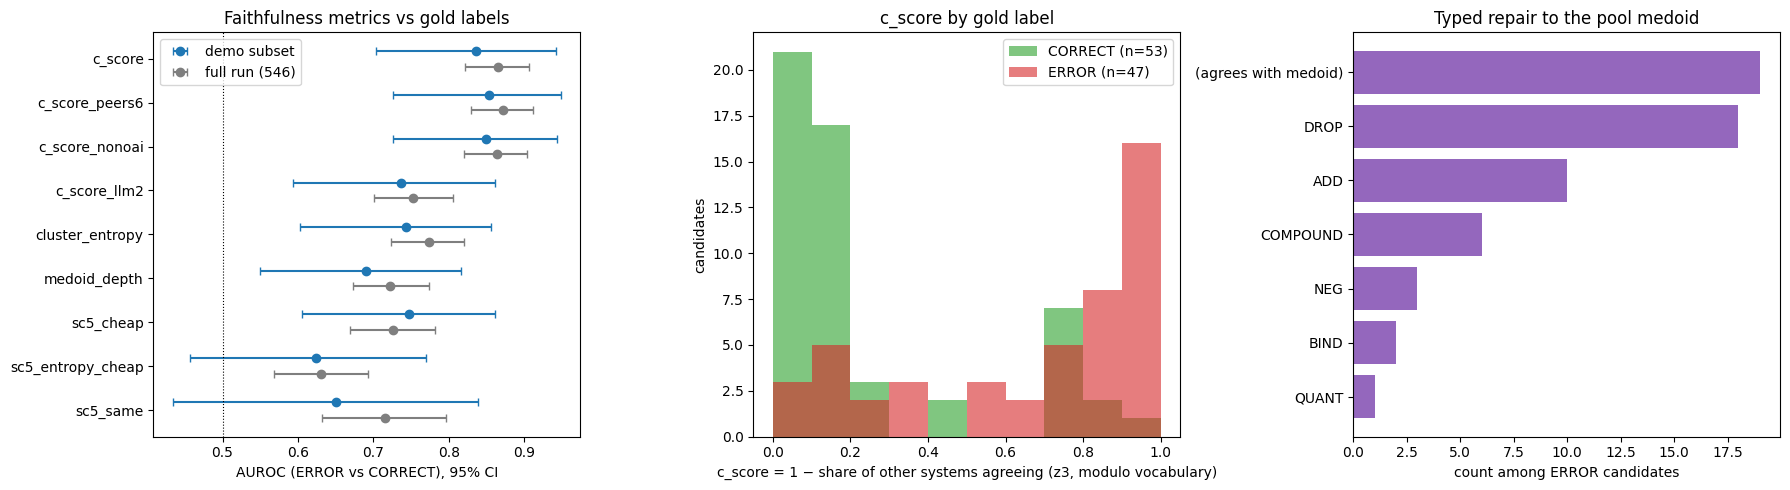

,system,label,c_score,medoid_depth,medoid_ops,sc5_cheap,text,candidate_fol
1,text-davinci-003,ERROR,1.0,3,[COMPOUND],1.0,All of New Vessel Press's published books are in English.,"∀x (Publish(x, newVesselPress) → English(x))"
3,gpt-4,ERROR,1.0,3,[COMPOUND],1.0,All of New Vessel Press's published books are in English.,"∀x (Book(x) ∧ Publish(newVesselPress, x) → English(x))"
25,gpt-4,ERROR,1.0,1,[DROP],1.0,"If a person gains knowledge, they become smarter.","∀x (Person(x) ∧ Gain(x, knowledge) → Smarter(x))"
22,gpt-4,ERROR,1.0,1,[DROP],1.0,Harry read the book “Walden” by Henry Thoreau.,"Person(harry) ∧ Book(walden) ∧ Read(harry, walden)"
21,gpt-3.5-turbo,ERROR,1.0,2,"[DROP, DROP]",1.0,Harry read the book “Walden” by Henry Thoreau.,"Read(harry, walden) ∧ Book(walden) ∧ Author(walden, henryThoreau)"
63,text-davinci-003,ERROR,1.0,1,[NEG],1.0,Roderick Strong leads the Creed Brothers.,"¬Lead(roderickStrong, creedBrothers)"
65,gpt-3.5-turbo,ERROR,1.0,1,[ADD],0.4,Some orchestras premiered music pieces.,"∃x ∃y (Orchestra(x) ∧ Premiered(x, y))"
48,text-davinci-003,ERROR,1.0,1,[QUANT],1.0,No digital media are analog.,¬∀x (Digital(x) → Analog(x))


In [17]:
full = data["full_run_headline"]
tab = pd.DataFrame([{"score": sc, "n": res[sc].get("n"), "n_err": res[sc].get("n_err"),
                     "AUROC (demo)": res[sc].get("auroc"), "CI95 (demo)": res[sc].get("auroc_ci95"),
                     "AUROC (full run)": full.get(sc, {}).get("auroc"), "CI95 (full run)": full.get(sc, {}).get("auroc_ci95")}
                    for sc in SCORES])
print(tab.to_string(index=False))
print()
print("Paired ΔAUROC c_score − sc5_cheap:", {k: delta[k] for k in ("n", "auroc_a", "auroc_b", "delta", "delta_ci95", "p_delta_le_0") if k in delta})
th = res["c_score"].get("threshold", {})
print(f"Medoid threshold (flag = medoid_depth ≥ 1): recall {th.get('recall')} {th.get('recall_ci95')}, "
      f"false alarms {th.get('false_alarm')} {th.get('false_alarm_ci95')}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ax = axes[0]
yv = np.arange(len(SCORES))
for off, lab, get, col in ((-0.18, "demo subset", lambda s: (res[s].get("auroc"), res[s].get("auroc_ci95")), "tab:blue"),
                           (0.18, "full run (546)", lambda s: (full.get(s, {}).get("auroc"), full.get(s, {}).get("auroc_ci95")), "tab:gray")):
    for i, s in enumerate(SCORES):
        a, c = get(s)
        if a is None:
            continue
        ax.errorbar(a, i + off, xerr=[[a - c[0]], [c[1] - a]] if c and c[0] is not None else None, fmt="o", color=col,
                    label=lab if i == 0 else None, capsize=3)
ax.axvline(0.5, color="k", lw=0.8, ls=":")
ax.set_yticks(yv); ax.set_yticklabels(SCORES); ax.invert_yaxis()
ax.set_xlabel("AUROC (ERROR vs CORRECT), 95% CI"); ax.set_title("Faithfulness metrics vs gold labels"); ax.legend(loc="upper left")

ax = axes[1]
bins_ = np.linspace(0, 1, 11)
for lab, col in (("CORRECT", "tab:green"), ("ERROR", "tab:red")):
    ax.hist(P.loc[P["label"] == lab, "c_score"], bins=bins_, alpha=0.6, color=col, label=f"{lab} (n={int((P['label'] == lab).sum())})")
ax.set_xlabel("c_score = 1 − share of other systems agreeing (z3, modulo vocabulary)"); ax.set_ylabel("candidates")
ax.set_title("c_score by gold label"); ax.legend()

ax = axes[2]
E = P[P["label"] == "ERROR"]
ops = Counter(o for lst in E["medoid_ops"] for o in (lst or ["(agrees with medoid)"]))
names, vals = zip(*ops.most_common(10)) if ops else ((), ())
ax.barh(list(names), list(vals), color="tab:purple"); ax.invert_yaxis()
ax.set_xlabel("count among ERROR candidates"); ax.set_title("Typed repair to the pool medoid")
plt.tight_layout(); plt.show()

show = P.sort_values("c_score", ascending=False)[["system", "label", "c_score", "medoid_depth", "medoid_ops", "sc5_cheap", "text", "candidate_fol"]]
pd.set_option("display.max_colwidth", 80)
show.head(8)